### Feature Engineering for Date and Time

A raw timestamp like `2024-03-15 14:32:00` means absolutely nothing to an ML model. It's just a large integer but hidden inside that timestamp is a rich set of signals: what month of the year (seasonality), what day of the week (weekly pattern), what hour (time of day behaviour), whether it's a holiday.

An e-commerce platform's order timestamps, contain patterns like "orders spike on Friday evenings", "returns increase in January after Christmas", and "night-time orders tend to be impulsive and more likely to be returned". None of that is visible in the raw timestamp, you have to extract it.

**In this notebook we will cover:**
1. Parsing date/time columns properly in pandas
2. Extracting year, month, day, hour, day-of-week, and more
3. Computing time deltas and duration features
4. Adding holiday indicators
5. Cyclical encoding : the correct way to encode periodic time features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

In [2]:
df = pd.read_csv("datetime_data.csv")

In [3]:
df.head()

,order_id,order_date_str,signup_date_str,delivery_date_str,order_amount
0,1,2024-05-10 08:23:00,2023-05-19,2024-05-11,363.266689
1,2,2024-11-10 22:04:00,2023-09-30,2024-11-17,15.916839
2,3,2022-05-02 13:57:00,2020-07-04,2022-05-05,271.859347
3,4,2023-04-12 19:35:00,2022-04-05,2023-04-20,108.398022
4,5,2022-11-27 16:51:00,2022-11-20,2022-11-30,115.042608


In [7]:
df.dtypes

order_id               int64
order_date_str        object
signup_date_str       object
delivery_date_str     object
order_amount         float64
dtype: object

Notice the dtypes output at the bottom, all three date columns are stored as plain strings (`object` dtype). pandas cannot extract months or days from a string. Before doing anything with a date column, the very first step is always to parse it into a proper `datetime64` type using `pd.to_datetime()`.

### Step One: Always Parse Your Dates

It's surprisingly common to receive data where dates are stored as strings especially when loaded from CSV files. Pandas reads datetime data as strings by default unless you tell it otherwise.

Once you parse a column with `pd.to_datetime()`, pandas gives you access to the `.dt` accessor, which unlocks dozens of useful properties. Think of parsing as flipping the switch that turns on all the date-engineering tools.

In [11]:
# Convert string columns to datetime
df['order_date']    = pd.to_datetime(df['order_date_str'])
df['signup_date']   = pd.to_datetime(df['signup_date_str'])
df['delivery_date'] = pd.to_datetime(df['delivery_date_str'])

In [13]:
df.dtypes

order_id                      int64
order_date_str               object
signup_date_str              object
delivery_date_str            object
order_amount                float64
order_date           datetime64[ns]
signup_date          datetime64[ns]
delivery_date        datetime64[ns]
dtype: object

In [15]:
df.head()

,order_id,order_date_str,signup_date_str,delivery_date_str,order_amount,order_date,signup_date,delivery_date
0,1,2024-05-10 08:23:00,2023-05-19,2024-05-11,363.266689,2024-05-10 08:23:00,2023-05-19,2024-05-11
1,2,2024-11-10 22:04:00,2023-09-30,2024-11-17,15.916839,2024-11-10 22:04:00,2023-09-30,2024-11-17
2,3,2022-05-02 13:57:00,2020-07-04,2022-05-05,271.859347,2022-05-02 13:57:00,2020-07-04,2022-05-05
3,4,2023-04-12 19:35:00,2022-04-05,2023-04-20,108.398022,2023-04-12 19:35:00,2022-04-05,2023-04-20
4,5,2022-11-27 16:51:00,2022-11-20,2022-11-30,115.042608,2022-11-27 16:51:00,2022-11-20,2022-11-30


In [17]:
df.drop(columns = ["order_date_str", "signup_date_str", "delivery_date_str"], inplace = True)

In [19]:
df.head()

,order_id,order_amount,order_date,signup_date,delivery_date
0,1,363.266689,2024-05-10 08:23:00,2023-05-19,2024-05-11
1,2,15.916839,2024-11-10 22:04:00,2023-09-30,2024-11-17
2,3,271.859347,2022-05-02 13:57:00,2020-07-04,2022-05-05
3,4,108.398022,2023-04-12 19:35:00,2022-04-05,2023-04-20
4,5,115.042608,2022-11-27 16:51:00,2022-11-20,2022-11-30


All three columns are now `datetime64[ns]` and Pandas knows they're dates, not strings. Now we can ask questions like "what month is this?" or "how many days between these two dates?" Let's start extracting useful features.

### Extracting Date-Time Components

The `.dt` accessor on a datetime column gives you access to every component of the date and time. Each component captures a different kind of temporal signal, and which ones are useful depends on your problem:

- **Year** captures long-term trends such as 2022 data might behave differently from 2024 data
- **Month** captures seasonality like sales spike in December, returns spike in January
- **Day of month** captures intra-month patterns like activity often picks up around paydays (1st and 15th)
- **Hour** captures intra-day behaviour like lunch orders, late-night purchases, morning commute browsing
- **Day of week** captures weekly patterns like weekends vs weekdays are completely different for most businesses
- **Quarter** captures business cycles like Q4 is often the most important quarter for retail

You can also derive binary indicators: `is_weekend`, `is_month_start`, `is_month_end`. These are simple but often surprisingly predictive.

In [23]:
od = df['order_date']

df['order_year']        = od.dt.year
df['order_month']       = od.dt.month
df['order_day']         = od.dt.day
df['order_hour']        = od.dt.hour
df['order_minute']      = od.dt.minute
df['order_dayofweek']   = od.dt.dayofweek    # 0=Monday, 6=Sunday
df['order_day_name']    = od.dt.day_name()
df['order_quarter']     = od.dt.quarter
df['order_weekofyear']  = od.dt.isocalendar().week.astype(int)
df['is_weekend']        = (od.dt.dayofweek >= 5).astype(int)
df['is_month_start']    = od.dt.is_month_start.astype(int)
df['is_month_end']      = od.dt.is_month_end.astype(int)

# Part of day
def part_of_day(hour):
    if 5 <= hour < 12:   return 'morning'
    elif 12 <= hour < 17: return 'afternoon'
    elif 17 <= hour < 21: return 'evening'
    else:                 return 'night'

df['part_of_day'] = df['order_hour'].apply(part_of_day)

df.head()

,order_id,order_amount,order_date,signup_date,delivery_date,order_year,order_month,order_day,order_hour,order_minute,order_dayofweek,order_day_name,order_quarter,order_weekofyear,is_weekend,is_month_start,is_month_end,part_of_day
0,1,363.266689,2024-05-10 08:23:00,2023-05-19,2024-05-11,2024,5,10,8,23,4,Friday,2,19,0,0,0,morning
1,2,15.916839,2024-11-10 22:04:00,2023-09-30,2024-11-17,2024,11,10,22,4,6,Sunday,4,45,1,0,0,night
2,3,271.859347,2022-05-02 13:57:00,2020-07-04,2022-05-05,2022,5,2,13,57,0,Monday,2,18,0,0,0,afternoon
3,4,108.398022,2023-04-12 19:35:00,2022-04-05,2023-04-20,2023,4,12,19,35,2,Wednesday,2,15,0,0,0,evening
4,5,115.042608,2022-11-27 16:51:00,2022-11-20,2022-11-30,2022,11,27,16,51,6,Sunday,4,47,1,0,0,afternoon


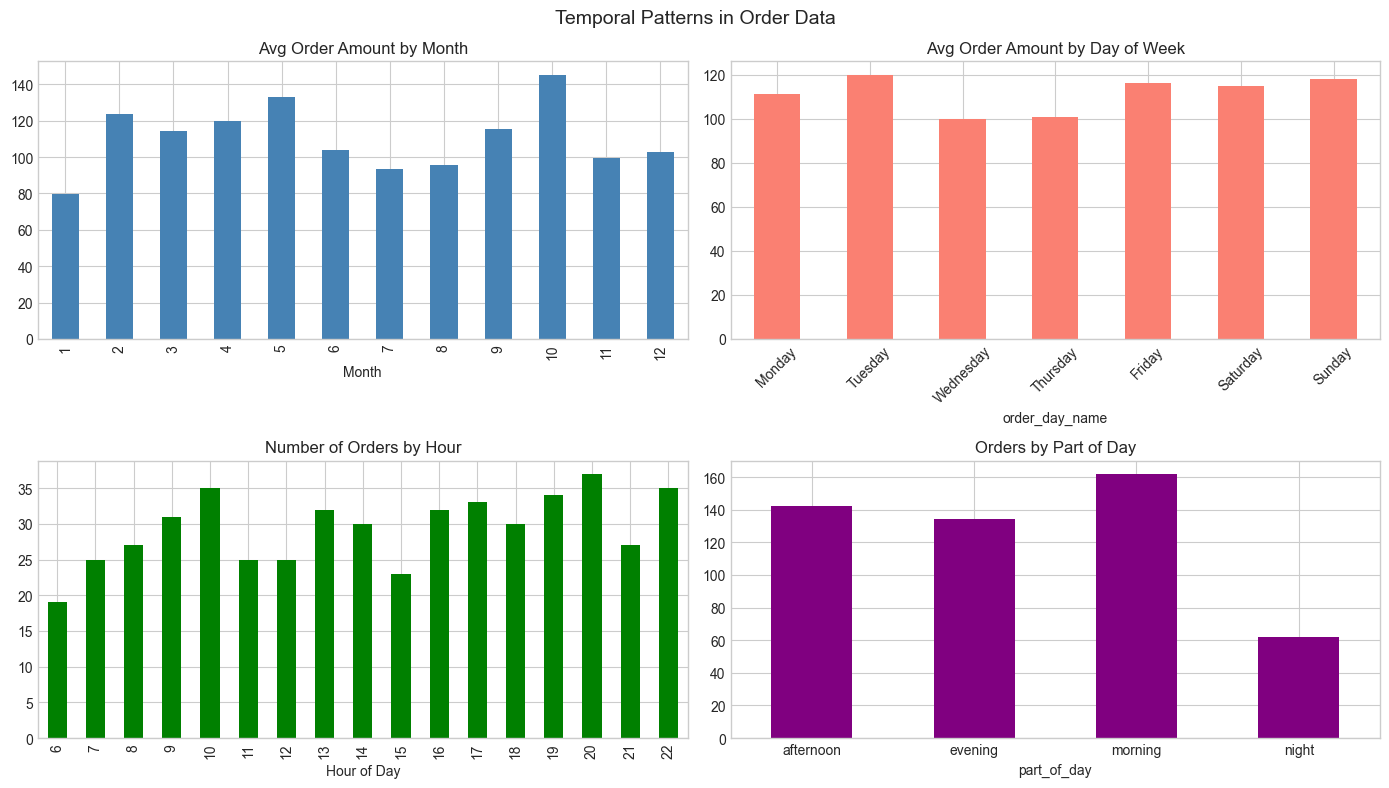

In [25]:
# Visualize temporal patterns
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Orders by month
df.groupby('order_month')['order_amount'].mean().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Avg Order Amount by Month')
axes[0,0].set_xlabel('Month')

# Orders by day of week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df.groupby('order_day_name')['order_amount'].mean().reindex(dow_order).plot(
    kind='bar', ax=axes[0,1], color='salmon'
)
axes[0,1].set_title('Avg Order Amount by Day of Week')
axes[0,1].tick_params(axis='x', rotation=45)

# Orders by hour
df.groupby('order_hour')['order_id'].count().plot(kind='bar', ax=axes[1,0], color='green')
axes[1,0].set_title('Number of Orders by Hour')
axes[1,0].set_xlabel('Hour of Day')

# Orders by part of day
df.groupby('part_of_day')['order_id'].count().plot(kind='bar', ax=axes[1,1], color='purple')
axes[1,1].set_title('Orders by Part of Day')
axes[1,1].tick_params(axis='x', rotation=0)

plt.suptitle('Temporal Patterns in Order Data', fontsize=14)
plt.tight_layout()
plt.show()

### Time Differences and Duration Features

Often the most informative feature isn't the date itself, but the *gap between two dates*. In e-commerce, how many days does it take from order to delivery? How long has this customer been with us? When did they last buy something?

These duration features capture behaviour and context that neither date alone reveals. A customer who signed up 3 years ago and is still active is a very different customer from one who signed up yesterday.

When you subtract two datetime columns in pandas, the result is a `Timedelta` object. Use `.dt.days` to get a plain integer you can feed into a model.

In [28]:
# Delivery duration
df['delivery_duration_days'] = (df['delivery_date'] - df['order_date']).dt.days

# Account age at time of order
df['account_age_days'] = (df['order_date'] - df['signup_date']).dt.days
df['account_age_years'] = df['account_age_days'] / 365.25

print('Time delta features:')
df[['order_date', 'signup_date', 'delivery_date', 'account_age_days', 'delivery_duration_days']].head(8)

Time delta features:


,order_date,signup_date,delivery_date,account_age_days,delivery_duration_days
0,2024-05-10 08:23:00,2023-05-19,2024-05-11,357,0
1,2024-11-10 22:04:00,2023-09-30,2024-11-17,407,6
2,2022-05-02 13:57:00,2020-07-04,2022-05-05,667,2
3,2023-04-12 19:35:00,2022-04-05,2023-04-20,372,7
4,2022-11-27 16:51:00,2022-11-20,2022-11-30,7,2
5,2022-03-29 20:18:00,2021-11-28,2022-03-30,121,0
6,2024-05-21 12:50:00,2023-06-09,2024-05-29,347,7
7,2022-05-11 16:57:00,2020-07-05,2022-05-14,675,2


In [30]:
print('\nDelivery duration (days):')
df['delivery_duration_days'].describe()


Delivery duration (days):


count    500.000000
mean       3.902000
std        2.664319
min        0.000000
25%        1.000000
50%        4.000000
75%        6.000000
max        8.000000
Name: delivery_duration_days, dtype: float64

In [32]:
print('\nAccount age (days):')
df['account_age_days'].describe()


Account age (days):


count    500.000000
mean     351.564000
std      217.100786
min        0.000000
25%      154.500000
50%      345.500000
75%      545.250000
max      729.000000
Name: account_age_days, dtype: float64

`account_age_days` ranges from 0 (brand new customer placing their first ever order) to over 700 (a customer who signed up nearly two years ago). A model predicting order value or churn can use this feature directly where long-tenure customers often have higher lifetime value and lower churn probability.

In [35]:
# Days since last purchase (requires multiple orders per customer)
# Simulate customer IDs
np.random.seed(42)
df['customer_id'] = np.random.randint(1, 101, 500)  # 100 customers, multiple orders each

# Sort by customer and date, then compute diff
df_sorted = df.sort_values(['customer_id', 'order_date'])
df_sorted['days_since_last_order'] = (df_sorted.groupby('customer_id')['order_date'].diff().dt.days)

print('Days since last order (first order per customer = NaN):')
df_sorted[['customer_id', 'order_date', 'days_since_last_order']].head(12)

Days since last order (first order per customer = NaN):


,customer_id,order_date,days_since_last_order
290,1,2022-02-20 13:01:00,NaN
486,1,2022-06-22 07:40:00,121.0
146,1,2022-08-08 20:47:00,47.0
274,1,2023-02-12 19:50:00,187.0
484,1,2023-11-16 15:41:00,276.0
491,1,2024-02-03 12:29:00,78.0
230,1,2024-03-08 17:56:00,34.0
112,1,2024-05-13 16:48:00,65.0
192,1,2024-10-11 16:18:00,150.0
224,2,2022-02-07 09:24:00,NaN


### Holiday Indicators

Behaviour changes dramatically on public holidays like sales spike on Black Friday, returns surge after Christmas and delivery times slow down during holiday periods.

A simple binary `is_holiday` flag where say 1 if the order date is a public holiday, 0 otherwise, can capture this effect directly. You can build this manually with a set of known holiday dates, or use the `holidays` Python package which knows the public holidays for every country and year automatically.

In [38]:
# Manual holiday lookup (US public holidays 2022-2024)
us_holidays = {
    '2022-01-01', '2022-07-04', '2022-11-24', '2022-12-25',
    '2023-01-01', '2023-07-04', '2023-11-23', '2023-12-25',
    '2024-01-01', '2024-07-04', '2024-11-28', '2024-12-25',}

df['is_holiday'] = df['order_date'].dt.strftime('%Y-%m-%d').isin(us_holidays).astype(int)

print(f'Orders on holidays: {df["is_holiday"].sum()}')
print('Average order amount on regular day vs holiday:')
df.groupby('is_holiday')['order_amount'].mean().round(2)

Orders on holidays: 2
Average order amount on regular day vs holiday:


is_holiday
0    111.17
1    200.35
Name: order_amount, dtype: float64

In [40]:
# Note: for production use, the 'holidays' Python package handles this automatically:
# pip install holidays
# import holidays
# us_hols = holidays.US(years=range(2022, 2025))
# df['is_holiday'] = df['order_date'].apply(lambda d: d in us_hols).astype(int)

### Cyclical Encoding : The Right Way to Handle Periodic Features

Here is a subtle but important problem. If we encode month as an integer (January=1, December=12), we're telling the model that January and December are 11 units apart. But on a calendar, they're only 1 month apart — December flows directly into January. The same problem exists for hours of the day (23:00 and 00:00 are consecutive), and days of the week (Sunday and Monday are adjacent).

Think of a clock face. All the hours sit on a circle. Hour 23 and hour 0 are right next to each other. Integer encoding stretches that circle into a line and breaks the neighbourhood relationship.

The solution is **`sine-cosine encoding`** where we map each value onto a circle using:
- `sin_feature = sin(2π × value / period)`
- `cos_feature = cos(2π × value / period)`

For months, the period is 12. For hours, 24. For days of the week, 7.

You always need *both* the sine and cosine components because one component alone will be ambiguous. March (month 3) and September (month 9) have the same sine value but different cosine values. Together, the pair uniquely locates every month on the circle.

In [43]:
# Cyclical encoding
df['month_sin'] = np.sin(2 * np.pi * df['order_month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['order_month'] / 12)

df['dow_sin'] = np.sin(2 * np.pi * df['order_dayofweek'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['order_dayofweek'] / 7)

df['hour_sin'] = np.sin(2 * np.pi * df['order_hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['order_hour'] / 24)

print('Cyclical encodings for month:')
month_demo = df.groupby('order_month')[['month_sin', 'month_cos']].mean().round(3)
month_demo

Cyclical encodings for month:


,month_sin,month_cos
order_month,,
1,0.500,0.866
2,0.866,0.500
3,1.000,0.000
4,0.866,-0.500
5,0.500,-0.866
6,0.000,-1.000
7,-0.500,-0.866
8,-0.866,-0.500
9,-1.000,-0.000


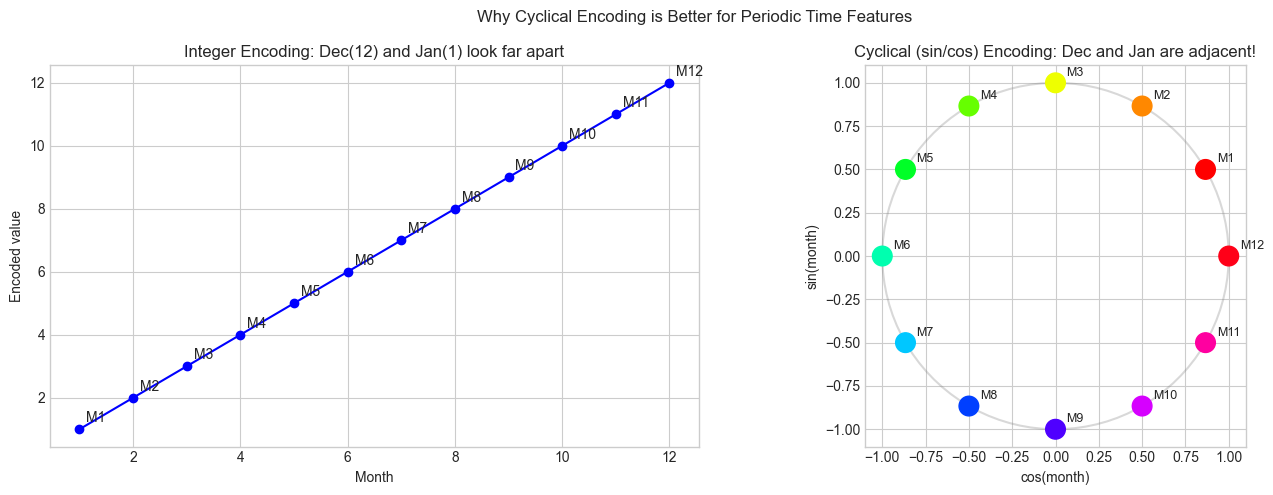

In [45]:
# Visualize the circular encoding
months = np.arange(1, 13)
month_sin = np.sin(2 * np.pi * months / 12)
month_cos = np.cos(2 * np.pi * months / 12)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: integer encoding
axes[0].plot(months, months, 'bo-')
for i, m in enumerate(months):
    axes[0].annotate(f'M{m}', (m, m), textcoords='offset points', xytext=(5,5))
axes[0].set_title('Integer Encoding: Dec(12) and Jan(1) look far apart')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Encoded value')

# Right: cyclical encoding
axes[1].scatter(month_cos, month_sin, c=months, cmap='hsv', s=200, zorder=5)
for i, m in enumerate(months):
    axes[1].annotate(f'M{m}', (month_cos[i], month_sin[i]),
                     textcoords='offset points', xytext=(8, 5), fontsize=9)
axes[1].set_title('Cyclical (sin/cos) Encoding: Dec and Jan are adjacent!')
axes[1].set_xlabel('cos(month)')
axes[1].set_ylabel('sin(month)')

# Draw the circle
theta = np.linspace(0, 2*np.pi, 100)
axes[1].plot(np.cos(theta), np.sin(theta), 'gray', alpha=0.3)
axes[1].set_aspect('equal')

plt.suptitle('Why Cyclical Encoding is Better for Periodic Time Features', fontsize=12)
plt.tight_layout()
plt.show()

The right-hand plot makes the point visually. In the circular encoding, December (M12) and January (M1) sit right next to each other on the circle, just like they are on a calendar. In the integer encoding on the left, they're at opposite ends of the scale. A model using integer month encoding will never learn that December and January are closer as it literally don't get that information in the data.

In [48]:
# Complete datetime feature engineering function
def extract_datetime_features(df, date_col):
    """Extract all useful features from a datetime column."""
    d = df[date_col]
    feats = pd.DataFrame(index=df.index)

    # Components
    feats[f'{date_col}_year']       = d.dt.year
    feats[f'{date_col}_month']      = d.dt.month
    feats[f'{date_col}_day']        = d.dt.day
    feats[f'{date_col}_hour']       = d.dt.hour
    feats[f'{date_col}_dayofweek']  = d.dt.dayofweek
    feats[f'{date_col}_quarter']    = d.dt.quarter
    feats[f'{date_col}_is_weekend'] = (d.dt.dayofweek >= 5).astype(int)
    feats[f'{date_col}_is_month_end'] = d.dt.is_month_end.astype(int)

    # Cyclical
    feats[f'{date_col}_month_sin']  = np.sin(2*np.pi*d.dt.month/12)
    feats[f'{date_col}_month_cos']  = np.cos(2*np.pi*d.dt.month/12)
    feats[f'{date_col}_dow_sin']    = np.sin(2*np.pi*d.dt.dayofweek/7)
    feats[f'{date_col}_dow_cos']    = np.cos(2*np.pi*d.dt.dayofweek/7)
    feats[f'{date_col}_hour_sin']   = np.sin(2*np.pi*d.dt.hour/24)
    feats[f'{date_col}_hour_cos']   = np.cos(2*np.pi*d.dt.hour/24)

    return feats

In [50]:
dt_features = extract_datetime_features(df, 'order_date')
print(f'Generated {dt_features.shape[1]} features from one datetime column:')
dt_features.columns.tolist()

Generated 14 features from one datetime column:


['order_date_year',
 'order_date_month',
 'order_date_day',
 'order_date_hour',
 'order_date_dayofweek',
 'order_date_quarter',
 'order_date_is_weekend',
 'order_date_is_month_end',
 'order_date_month_sin',
 'order_date_month_cos',
 'order_date_dow_sin',
 'order_date_dow_cos',
 'order_date_hour_sin',
 'order_date_hour_cos']

### <font color='green'>Key things to remember from this notebook</font>

Always parse string dates to `datetime64` before doing anything else. Extract the components that are relevant to your domain such as month and day-of-week almost always matter, also hour matters for intra-day businesses. Compute duration features (account age, days since last purchase) because time gaps are often more predictive than the raw date. And use sine-cosine encoding for any periodic feature where the wrap-around matters and here month, hour, and day of week all qualify.